In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

In [16]:
cleaned_path = 'Assignment 1 (Advanced)/data/dataset_mood_smartphone_cleaned.csv'
daily_df = pd.read_csv(cleaned_path)
daily_df.head()

,id,date,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,...,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,circumplex.arousal,circumplex.valence,mood,screen,sms
0,AS14.01,2014-02-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2.0
1,AS14.01,2014-02-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2.0
2,AS14.01,2014-02-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,2.0
3,AS14.01,2014-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,3.0
4,AS14.01,2014-02-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,1.0


## Sliding Window Feature Engineering from Claude

This code varifies the importance of the mood lags. I kept this in to validate for later when the code is actually cleaned.
Deze code bevestigt de nut van de mood lags. Ik heb hem erin gehouden om later m'n methode te bevestigen en omdat deze code de average rolling mood maakt van 7 dagen die ik nodig heb.


For each patient, we slide a window of `W` days over their daily time series. From each window we extract:

- **Aggregation features**: mean, std, min, max of each variable over the window
- **Trend features**: linear slope of each variable over the window (captures direction of change)
- **Lag features**: mood values from the previous 1, 2, and 3 days
- **Temporal features**: day of the week (cyclical encoding)
- **Target**: the average mood on the *next* day after the window

In [17]:
# Configuration
WINDOW_SIZE = 7  # number of days in the history window
N_LAGS = 3       # number of mood lag features

# Feature columns (all variables except id and date)
feature_vars = [c for c in daily_df.columns if c not in ['id', 'date']]

In [18]:
def compute_slope(series):
    """Compute linear trend (slope) over a series. Returns NaN if not enough data."""
    y = series.dropna()
    if len(y) < 2:
        return np.nan
    x = np.arange(len(y))
    slope, _, _, _, _ = stats.linregress(x, y)
    return slope


def build_sliding_window_features(patient_df, feature_vars, window_size, n_lags):
    """
    Build feature rows from a single patient's daily data using a sliding window.
    
    For each valid position t (where we have window_size days of history and
    a next-day target), we create one instance with:
    - Rolling aggregation features (mean, std, min, max) over the window
    - Trend (slope) over the window
    - Lag features for mood
    - Day-of-week (sin/cos encoded)
    - Target: next-day mood
    """
    patient_df = patient_df.sort_values('date').reset_index(drop=True)
    n_days = len(patient_df)
    instances = []

    for t in range(window_size, n_days):
        # Window: days [t - window_size, t) ; Target: day t
        window = patient_df.iloc[t - window_size : t]
        target_row = patient_df.iloc[t]

        # Skip if target mood is missing
        if pd.isna(target_row['mood']):
            continue

        row = {
            'id': patient_df.iloc[t]['id'],
            'date': target_row['date'],
            'target_mood': target_row['mood'],
        }

        # Aggregation features over the window
        for var in feature_vars:
            vals = window[var]
            row[f'{var}_mean'] = vals.mean()
            row[f'{var}_std'] = vals.std()
            row[f'{var}_min'] = vals.min()
            row[f'{var}_max'] = vals.max()
            row[f'{var}_trend'] = compute_slope(vals)

        # Lag features for mood (mood on day t-1, t-2, t-3, ...)
        for lag in range(1, n_lags + 1):
            lag_idx = t - lag
            if lag_idx >= 0:
                row[f'mood_lag{lag}'] = patient_df.iloc[lag_idx]['mood']
            else:
                row[f'mood_lag{lag}'] = np.nan

        # Day-of-week features (cyclical encoding)
        target_date = pd.to_datetime(target_row['date'])
        dow = target_date.dayofweek  # 0=Monday, 6=Sunday
        row['dow_sin'] = np.sin(2 * np.pi * dow / 7)
        row['dow_cos'] = np.cos(2 * np.pi * dow / 7)

        instances.append(row)

    return pd.DataFrame(instances)


print("Feature engineering function defined.")

Feature engineering function defined.


In [19]:
# Apply sliding window feature engineering per patient
patient_ids = sorted(daily_df['id'].unique())
all_instances = []

for pid in patient_ids:
    patient_data = daily_df[daily_df['id'] == pid].copy()
    patient_features = build_sliding_window_features(
        patient_data, feature_vars, WINDOW_SIZE, N_LAGS
    )
    all_instances.append(patient_features)

features_df = pd.concat(all_instances, ignore_index=True)

print(f"Total instances created: {len(features_df)}")
print(f"Patients represented: {features_df['id'].nunique()}")
print(f"Instances per patient:")
print(features_df.groupby('id').size().describe())
print(f"\nTotal features: {len([c for c in features_df.columns if c not in ['id', 'date', 'target_mood']])})")

Total instances created: 1300
Patients represented: 27
Instances per patient:
count    27.000000
mean     48.148148
std       8.174556
min      31.000000
25%      43.500000
50%      47.000000
75%      53.000000
max      69.000000
dtype: float64

Total features: 100)


In [20]:
# Preview the feature matrix
print("Feature columns:")
feature_cols = [c for c in features_df.columns if c not in ['id', 'date', 'target_mood']]
for i, col in enumerate(feature_cols):
    print(f"  {i+1:3d}. {col}")

print(f"\nTarget distribution:")
print(features_df['target_mood'].describe())
features_df.head()

Feature columns:
    1. activity_mean
    2. activity_std
    3. activity_min
    4. activity_max
    5. activity_trend
    6. appCat.builtin_mean
    7. appCat.builtin_std
    8. appCat.builtin_min
    9. appCat.builtin_max
   10. appCat.builtin_trend
   11. appCat.communication_mean
   12. appCat.communication_std
   13. appCat.communication_min
   14. appCat.communication_max
   15. appCat.communication_trend
   16. appCat.entertainment_mean
   17. appCat.entertainment_std
   18. appCat.entertainment_min
   19. appCat.entertainment_max
   20. appCat.entertainment_trend
   21. appCat.finance_mean
   22. appCat.finance_std
   23. appCat.finance_min
   24. appCat.finance_max
   25. appCat.finance_trend
   26. appCat.game_mean
   27. appCat.game_std
   28. appCat.game_min
   29. appCat.game_max
   30. appCat.game_trend
   31. appCat.office_mean
   32. appCat.office_std
   33. appCat.office_min
   34. appCat.office_max
   35. appCat.office_trend
   36. appCat.other_mean
   37. appCat.oth

,id,date,target_mood,activity_mean,activity_std,activity_min,activity_max,activity_trend,appCat.builtin_mean,appCat.builtin_std,...,sms_mean,sms_std,sms_min,sms_max,sms_trend,mood_lag1,mood_lag2,mood_lag3,dow_sin,dow_cos
0,AS14.01,2014-02-26,6.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.714286,0.755929,1.0,3.0,-7.142857e-02,NaN,NaN,NaN,0.974928,-0.222521
1,AS14.01,2014-02-27,6.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.714286,0.755929,1.0,3.0,-7.930164e-18,6.25,NaN,NaN,0.433884,-0.900969
2,AS14.01,2014-03-21,6.200000,0.081548,NaN,0.081548,0.081548,NaN,3.036650,NaN,...,1.714286,0.755929,1.0,3.0,1.428571e-01,NaN,NaN,NaN,-0.433884,-0.900969
3,AS14.01,2014-03-22,6.400000,0.107799,0.037125,0.081548,0.134050,0.052502,4.281627,1.760663,...,1.714286,0.755929,1.0,3.0,-3.571429e-02,6.20,NaN,NaN,-0.974928,-0.222521
4,AS14.01,2014-03-23,6.800000,0.150826,0.079013,0.081548,0.236880,0.077666,4.563153,1.337063,...,1.714286,0.755929,1.0,3.0,-2.142857e-01,6.40,6.2,NaN,-0.781831,0.623490


In [8]:
# Handle remaining NaN values
print("NaN counts before handling:")
nan_counts = features_df.isnull().sum()
print(nan_counts[nan_counts > 0])

# For features with NaN (e.g., from std of constant windows, or missing arousal/valence),
# fill with 0 for std columns and forward-fill or median for others
std_cols = [c for c in features_df.columns if c.endswith('_std')]
features_df[std_cols] = features_df[std_cols].fillna(0)

# For remaining NaN features, fill with column median per patient
remaining_nan_cols = features_df.columns[features_df.isnull().any()]
for col in remaining_nan_cols:
    if col in ['id', 'date', 'target_mood']:
        continue
    features_df[col] = features_df.groupby('id')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # If still NaN (entire patient missing), fill with global median
    features_df[col] = features_df[col].fillna(features_df[col].median())

# Drop any remaining rows where target is missing
features_df = features_df.dropna(subset=['target_mood']).reset_index(drop=True)

print(f"\nFinal dataset shape: {features_df.shape}")
print(f"Remaining NaN values: {features_df.isnull().sum().sum()}")

NaN counts before handling:
activity_mean     109
activity_std      138
activity_min      109
activity_max      109
activity_trend    138
                 ... 
sms_max           115
sms_trend         178
mood_lag1          29
mood_lag2          57
mood_lag3          84
Length: 98, dtype: int64

Final dataset shape: (1300, 103)
Remaining NaN values: 0


In [21]:
# Compute correlations between all features and the target
feature_cols = [c for c in features_df.columns if c not in ['id', 'date', 'target_mood']]
correlations = features_df[feature_cols].corrwith(features_df['target_mood']).sort_values(ascending=False)

# Show top 20 positively and negatively correlated features
print("Top 20 features most POSITIVELY correlated with next-day mood:")
print(correlations.head(20).to_string())
print(f"\nTop 20 features most NEGATIVELY correlated with next-day mood:")
print(correlations.tail(20).to_string())

Top 20 features most POSITIVELY correlated with next-day mood:
mood_mean                   0.506910
mood_lag1                   0.481334
mood_min                    0.450163
mood_lag2                   0.390680
mood_max                    0.365715
mood_lag3                   0.292124
circumplex.valence_mean     0.253899
circumplex.valence_min      0.247949
circumplex.valence_max      0.168666
appCat.game_max             0.141318
appCat.weather_trend        0.129062
appCat.game_mean            0.127778
activity_min                0.120535
appCat.communication_min    0.105567
appCat.travel_mean          0.095160
activity_mean               0.093146
appCat.travel_max           0.088915
appCat.unknown_trend        0.088398
appCat.game_std             0.082286
appCat.other_min            0.078349

Top 20 features most NEGATIVELY correlated with next-day mood:
sms_mean                   -0.069613
appCat.social_max          -0.073298
appCat.unknown_mean        -0.076507
appCat.social_std     

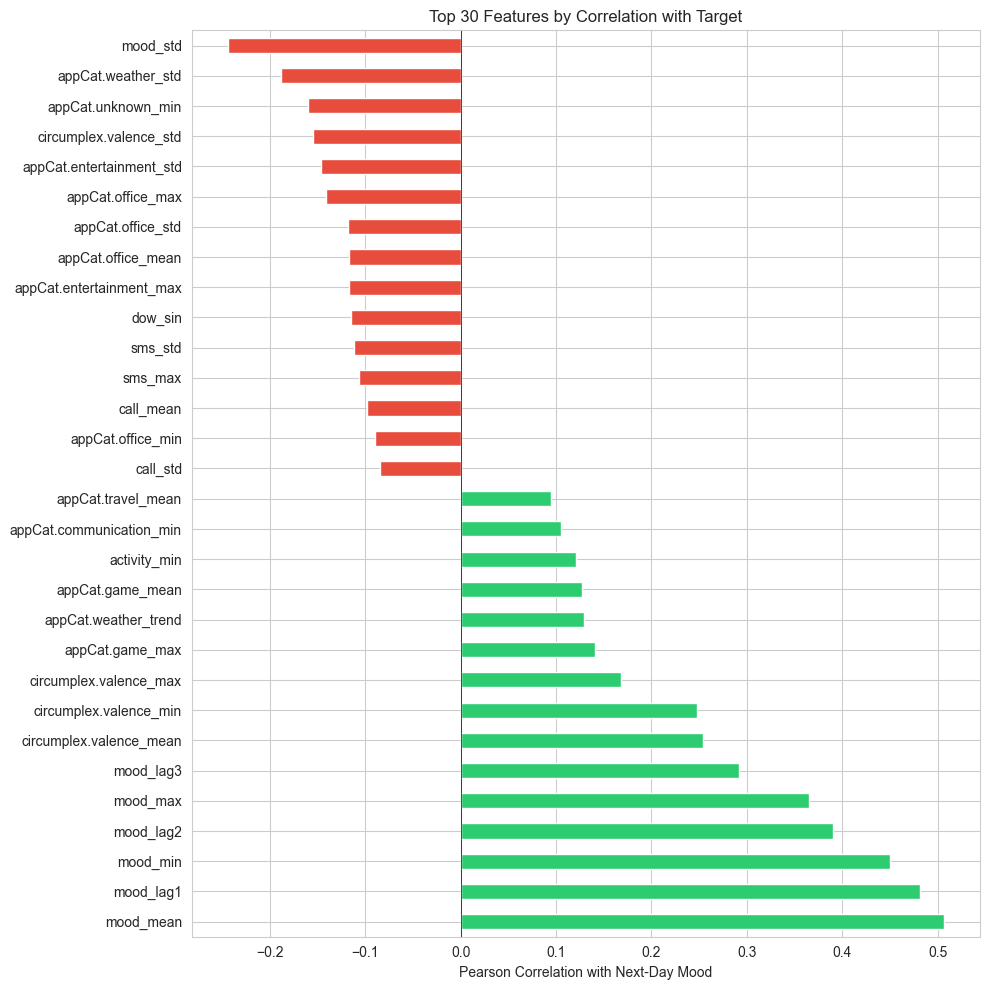

In [22]:
# Visualize top correlated features
top_n = 30
top_corr = pd.concat([correlations.head(top_n // 2), correlations.tail(top_n // 2)])

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_corr.values]
top_corr.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Pearson Correlation with Next-Day Mood')
ax.set_title(f'Top {top_n} Features by Correlation with Target')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

In [23]:
# Feature importance using a quick Random Forest
from sklearn.ensemble import RandomForestRegressor

X = features_df[feature_cols].copy()
y = features_df['target_mood'].copy()

# Drop any columns that are all NaN or constant
valid_cols = X.columns[X.std() > 0]
X = X[valid_cols]

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 20 features by Random Forest importance:")
print(importances.head(20).to_string())
print(f"\nRF R-squared (training, for reference): {rf.score(X, y):.3f}")

Top 20 features by Random Forest importance:
mood_mean                     0.187524
mood_lag1                     0.107254
appCat.other_trend            0.020250
mood_lag3                     0.018566
call_trend                    0.017354
mood_lag2                     0.017085
mood_std                      0.015895
appCat.entertainment_trend    0.015367
circumplex.arousal_trend      0.014896
sms_trend                     0.014761
call_std                      0.014669
activity_trend                0.014523
dow_sin                       0.014241
activity_std                  0.013093
circumplex.valence_mean       0.012118
screen_std                    0.011227
appCat.other_std              0.011206
mood_trend                    0.011181
sms_std                       0.011163
appCat.entertainment_min      0.011158

RF R-squared (training, for reference): 0.895


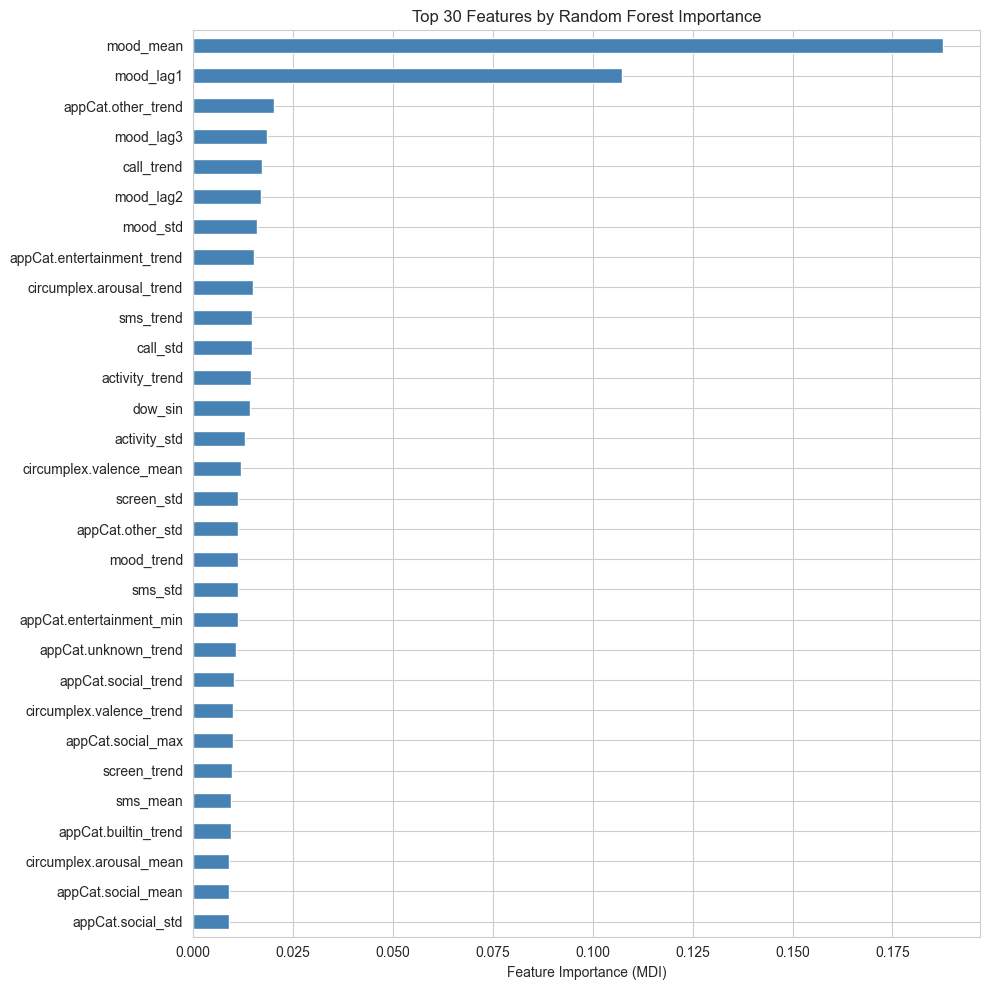

In [24]:
# Visualize Random Forest feature importances
fig, ax = plt.subplots(figsize=(10, 10))
importances.head(30).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (MDI)')
ax.set_title('Top 30 Features by Random Forest Importance')
plt.tight_layout()
plt.show()

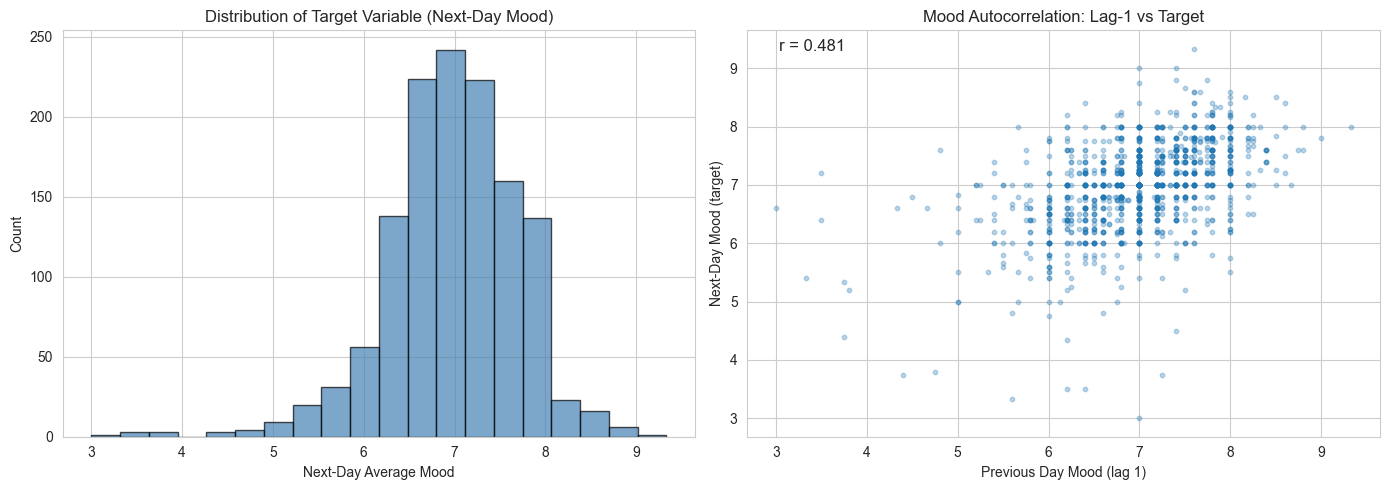

In [25]:
# Target distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(features_df['target_mood'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Next-Day Average Mood')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Target Variable (Next-Day Mood)')

# Scatter: mood_lag1 vs target
axes[1].scatter(features_df['mood_lag1'], features_df['target_mood'], alpha=0.3, s=10)
axes[1].set_xlabel('Previous Day Mood (lag 1)')
axes[1].set_ylabel('Next-Day Mood (target)')
axes[1].set_title('Mood Autocorrelation: Lag-1 vs Target')
r = features_df[['mood_lag1', 'target_mood']].corr().iloc[0, 1]
axes[1].annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)

plt.tight_layout()
plt.show()

## Statistical Lag Analysis of Mood

1. **ACF** 
2. **PACF** 
3. **ADF test** 
4. **Ljung-Box test**

In [ ]:
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats as scipy_stats
import matplotlib.gridspec as gridspec         


In [33]:
mood_series_by_patient = {}
for pid, grp in daily_df.groupby('id'):
    s = grp.sort_values('date')['mood'].reset_index(drop=True)
    mood_series_by_patient[pid] = s.dropna()

pooled_mood = pd.concat(
    [s - s.mean() for s in mood_series_by_patient.values()],
    ignore_index=True
)


In [ ]:
# Augmented Dickey-Fuller Stationarity Test
# To test the stationarity of each mood series such that ACF/PACF assumptions hold.
print("=" * 60)
print("ADF Stationarity Test — per patient (mood series)")
print("=" * 60)

adf_results = []
for pid, s in mood_series_by_patient.items():
    if len(s) < 10:
        continue
    adf_stat, p_val, _, _, crit, _ = adfuller(s, autolag='AIC')
    adf_results.append({
        'patient': pid,
        'ADF_stat': round(adf_stat, 3),
        'p_value': round(p_val, 4),
        'stationary': p_val < 0.05
    })

adf_df = pd.DataFrame(adf_results)
print(adf_df.to_string(index=False))

ADF Stationarity Test — per patient (mood series)
patient  ADF_stat  p_value  stationary
AS14.01    -3.518   0.0075        True
AS14.02    -3.885   0.0021        True
AS14.03    -5.419   0.0000        True
AS14.05    -2.630   0.0869       False
AS14.06    -6.844   0.0000        True
AS14.07    -5.864   0.0000        True
AS14.08    -5.478   0.0000        True
AS14.09    -3.180   0.0212        True
AS14.12    -2.897   0.0457        True
AS14.13    -2.821   0.0554       False
AS14.14    -4.243   0.0006        True
AS14.15    -5.797   0.0000        True
AS14.16    -3.040   0.0314        True
AS14.17    -4.427   0.0003        True
AS14.19    -4.690   0.0001        True
AS14.20    -5.531   0.0000        True
AS14.23    -2.821   0.0553       False
AS14.24    -6.303   0.0000        True
AS14.25    -5.037   0.0000        True
AS14.26    -5.953   0.0000        True
AS14.27    -4.997   0.0000        True
AS14.28    -6.133   0.0000        True
AS14.29    -3.404   0.0108        True
AS14.30    -8.

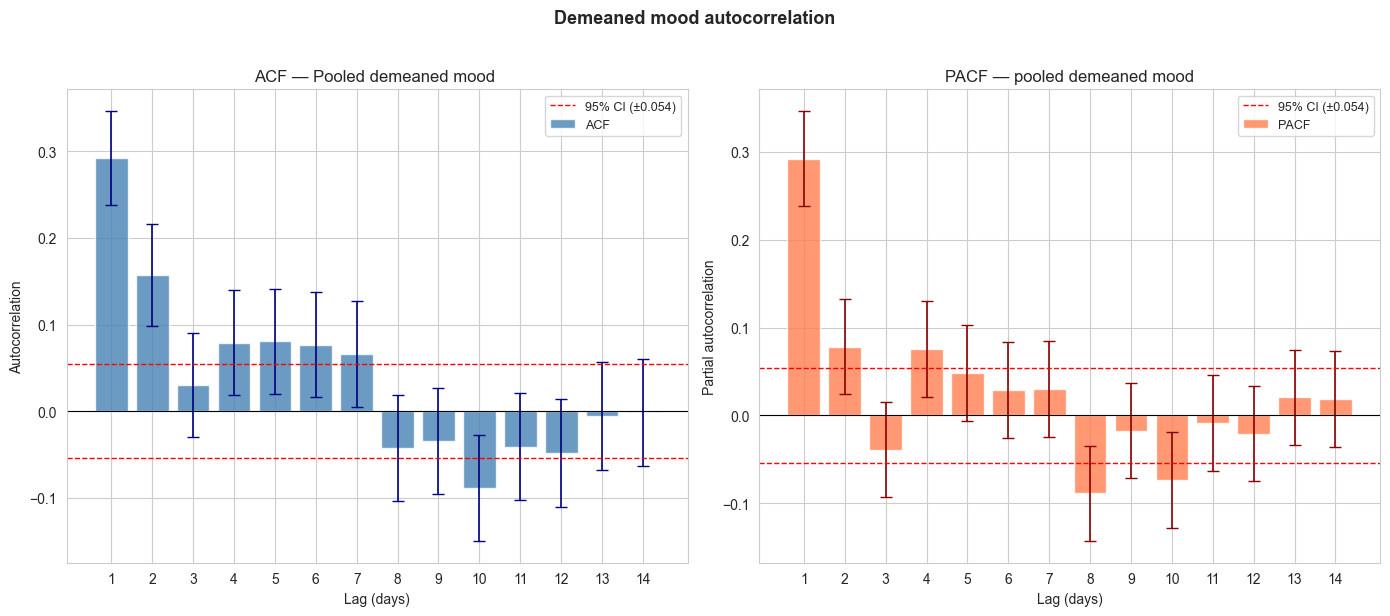

In [34]:
# 2. ACF and PACF
alpha = 0.05
n = len(pooled_mood)

acf_vals, acf_confint = acf(pooled_mood, nlags= 14, alpha=alpha)
pacf_vals, pacf_confint = pacf(pooled_mood, nlags= 14, alpha=alpha, method='ywmle')

# CI
acf_ci  = acf_confint[:, 1]  - acf_vals  
pacf_ci = pacf_confint[:, 1] - pacf_vals

lags = np.arange(14 + 1)

fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig)

# --- ACF ---
ax1 = fig.add_subplot(gs[0])
ax1.bar(lags[1:], acf_vals[1:], color='steelblue', alpha=0.8, label='ACF')
ax1.errorbar(lags[1:], acf_vals[1:], yerr=acf_ci[1:], fmt='none',
             color='navy', capsize=4, linewidth=1.2)
ax1.axhline(0, color='black', linewidth=0.8)
ci_bound = 1.96 / np.sqrt(n)
ax1.axhline( ci_bound, color='red', linestyle='--', linewidth=1, label=f'95% CI (±{ci_bound:.3f})')
ax1.axhline(-ci_bound, color='red', linestyle='--', linewidth=1)
ax1.set_xlabel('Lag (days)')
ax1.set_ylabel('Autocorrelation')
ax1.set_title('ACF — Pooled demeaned mood ')
ax1.set_xticks(lags[1:])
ax1.legend(fontsize=9)

# --- PACF ---
ax2 = fig.add_subplot(gs[1])
ax2.bar(lags[1:], pacf_vals[1:], color='coral', alpha=0.8, label='PACF')
ax2.errorbar(lags[1:], pacf_vals[1:], yerr=pacf_ci[1:], fmt='none',
             color='darkred', capsize=4, linewidth=1.2)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline( ci_bound, color='red', linestyle='--', linewidth=1, label=f'95% CI (±{ci_bound:.3f})')
ax2.axhline(-ci_bound, color='red', linestyle='--', linewidth=1)
ax2.set_xlabel('Lag (days)')
ax2.set_ylabel('Partial autocorrelation')
ax2.set_title('PACF — pooled demeaned mood')
ax2.set_xticks(lags[1:])
ax2.legend(fontsize=9)

plt.suptitle('Demeaned mood autocorrelation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [36]:
# Ljung-Box Test

lb_results = acorr_ljungbox(pooled_mood, lags=list(range(1, 14 + 1)), return_df=True)
lb_results.index.name = 'lag'
lb_results.columns  = ['LB_stat', 'p_value']
lb_results['significant'] = lb_results['p_value'] < 0.05

print("Ljung-Box test on pooled mood series:")
print(lb_results.to_string())


Ljung-Box test on pooled mood series:
        LB_stat       p_value  significant
lag                                       
1    111.194945  5.362908e-26         True
2    143.367984  7.379684e-32         True
3    144.535048  3.976618e-31         True
4    152.735962  5.276773e-32         True
5    161.273301  5.298630e-33         True
6    168.982741  7.391592e-34         True
7    174.700403  2.560571e-34         True
8    177.084347  4.214227e-34         True
9    178.650201  9.694433e-34         True
10   188.925745  3.271240e-35         True
11   191.138374  5.106453e-35         True
12   194.170345  5.196864e-35         True
13   194.207867  2.108264e-34         True
14   194.209408  8.345736e-34         True


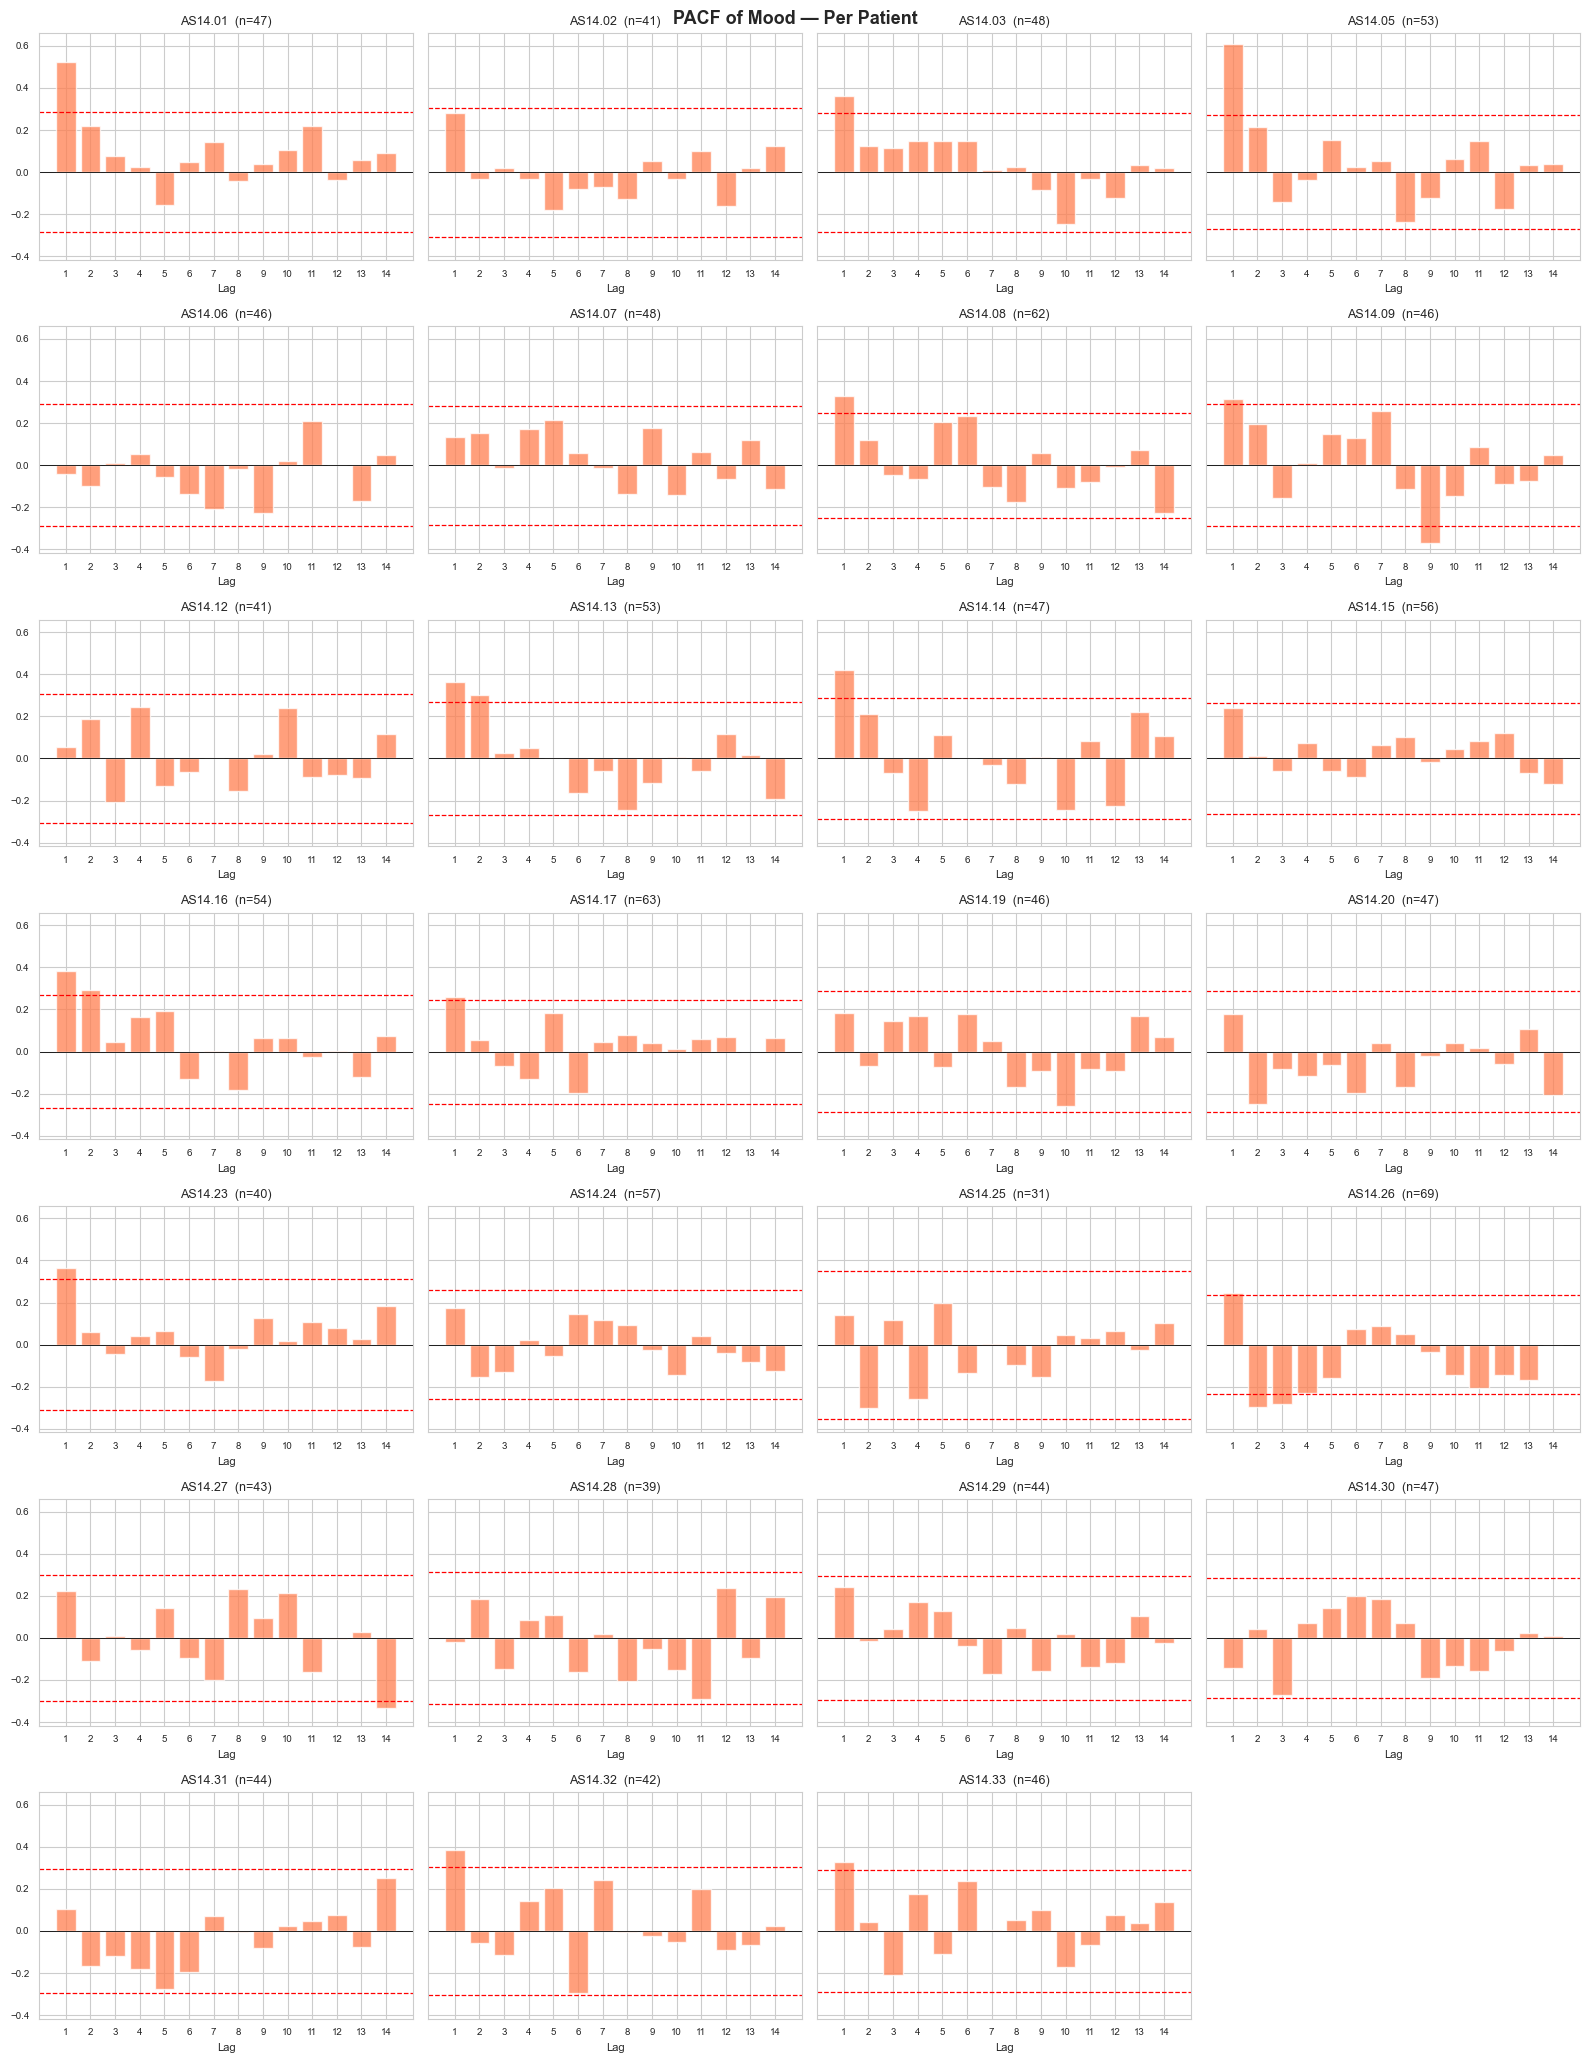

In [37]:
# Per-Patient PACF
# De meeste patienten tonen autocorrelatie in de eerste paar dagen, maar dit is niet consistent.
# Misschien beter niet laten zien?

pids = sorted(mood_series_by_patient.keys())
n_patients = len(pids)
ncols = 4
nrows = int(np.ceil(n_patients / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), sharey=True)
axes = axes.flatten()

for i, pid in enumerate(pids):
    s = mood_series_by_patient[pid]
    ax = axes[i]
    max_l = min(14, len(s) // 2 - 1)
    if max_l < 2:
        ax.set_title(f'{pid}\n(too short)', fontsize=9)
        ax.axis('off')
        continue
    try:
        pv, pv_ci = pacf(s, nlags=max_l, alpha= 0.05, method='ywmle')
    except Exception:
        ax.set_title(f'{pid}\n(error)', fontsize=9)
        ax.axis('off')
        continue

    l_range = np.arange(1, max_l + 1)
    ci_h = 1.96 / np.sqrt(len(s))
    ax.bar(l_range, pv[1:], color='coral', alpha=0.75)
    ax.axhline( ci_h, color='red', linestyle='--', linewidth=0.9)
    ax.axhline(-ci_h, color='red', linestyle='--', linewidth=0.9)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_title(f'{pid}  (n={len(s)})', fontsize=9)
    ax.set_xlabel('Lag', fontsize=8)
    ax.set_xticks(l_range)
    ax.tick_params(labelsize=7)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('PACF of Mood — Per Patient', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [63]:
features_df[["target_mood", "mood_mean"]]

,target_mood,mood_mean
0,6.250000,6.985714
1,6.333333,6.250000
2,6.200000,6.985714
3,6.400000,6.200000
4,6.800000,6.300000
...,...,...
1295,6.200000,5.983333
1296,8.200000,5.976190
1297,7.000000,6.290476
1298,6.800000,6.469048


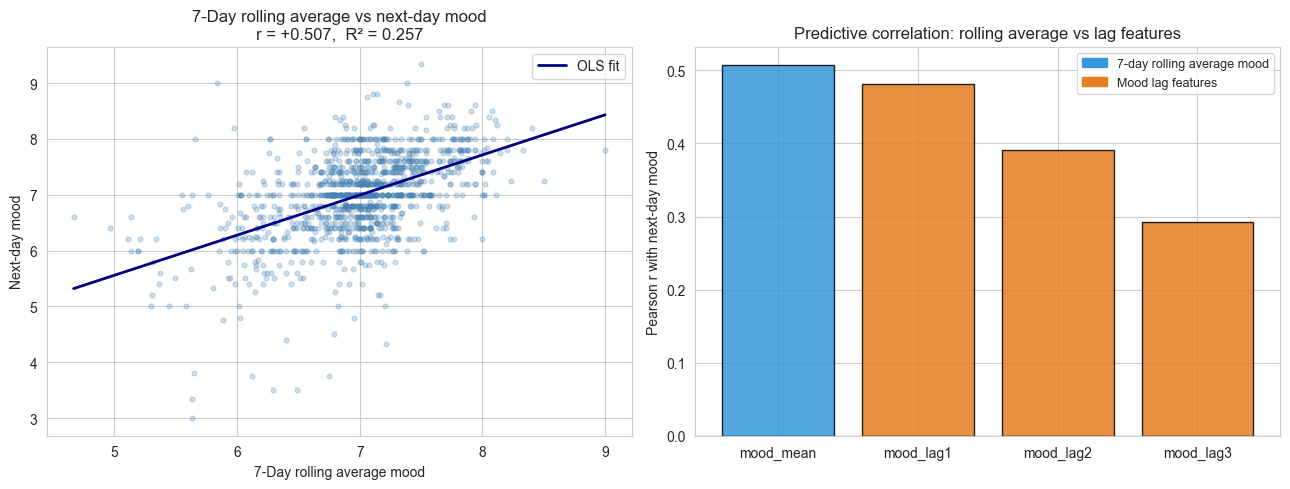

In [42]:
# 7-Day Rolling Mean + lags vs Next-Day Mood

from scipy import stats as scipy_stats

target_col = 'target_mood'
rolling_col = 'mood_mean'

lag_cols = [f'mood_lag{k}' for k in range(1, N_LAGS + 1)]
present   = [c for c in lag_cols if c in features_df.columns]

records = []
for col in present:
    valid = features_df[['target_mood', col]].dropna()
    r, p  = scipy_stats.pearsonr(valid['target_mood'], valid[col])
    records.append({
        'lag_feature': col,
        'n_pairs':     len(valid),
        'pearson_r':   round(r, 4),
        'p_value':     round(p, 6),
        'significant': p < 0.05,
        'r_squared':   round(r**2, 4)
    })

lag_summary = pd.DataFrame(records)

valid = features_df[[target_col, rolling_col]].dropna()
r_roll, p_roll = scipy_stats.pearsonr(valid[target_col], valid[rolling_col])
r2_roll = r_roll ** 2

all_rows = [{'lag_feature': rolling_col, 'pearson_r': r_roll,
             'r_squared': r2_roll, 'p_value': p_roll,
             'significant': p_roll < 0.05}]
all_rows += lag_summary.to_dict('records')

# ── Scatter plot: rolling mean vs target ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(valid[rolling_col], valid[target_col], alpha=0.25, s=12, color='steelblue')
m, b = np.polyfit(valid[rolling_col], valid[target_col], 1)
xs = np.linspace(valid[rolling_col].min(), valid[rolling_col].max(), 200)
axes[0].plot(xs, m * xs + b, color='navy', linewidth=2, label=f'OLS fit')
axes[0].set_xlabel('7-Day rolling average mood')
axes[0].set_ylabel('Next-day mood')
axes[0].set_title(f'7-Day rolling average vs next-day mood\nr = {r_roll:+.3f},  R² = {r2_roll:.3f}')
axes[0].legend()

# ── Bar chart comparing all predictors ────────────────────────────────────────
labels = [row['lag_feature'] for row in all_rows]
rs     = [row['pearson_r']   for row in all_rows]
colors = ['#3498db' if l == rolling_col else '#e67e22' for l in labels]

axes[1].bar(labels, rs, color=colors, edgecolor='black', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Pearson r with next-day mood')
axes[1].set_title('Predictive correlation: rolling average vs lag features')
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='#3498db', label='7-day rolling average mood'),
    Patch(color='#e67e22', label='Mood lag features')
], fontsize=9)

plt.tight_layout()
plt.show()


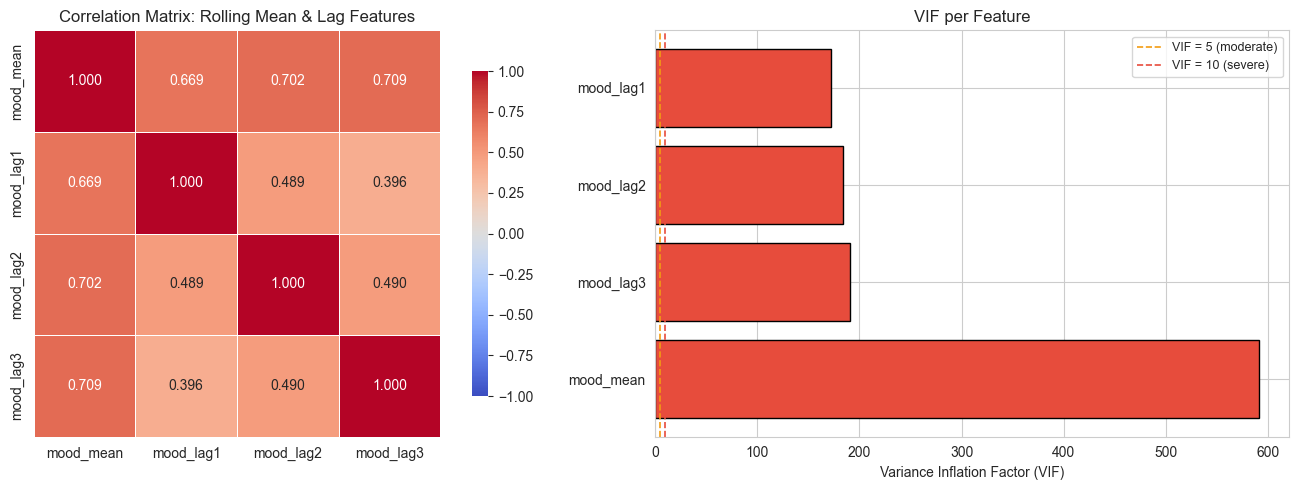

  feature        VIF
mood_mean 591.022639
mood_lag3 190.724971
mood_lag2 183.891953
mood_lag1 172.429707


In [43]:
# Multicollinearity Check
from statsmodels.stats.outliers_influence import variance_inflation_factor

mc_cols = ['mood_mean'] + [f'mood_lag{k}' for k in range(1, N_LAGS + 1)]
mc_df   = features_df[mc_cols].dropna()

corr_matrix = mc_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=axes[0], square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Matrix: Rolling Mean & Lag Features')

# Variance inflation factor (VIF)
vif_data = pd.DataFrame({
    'feature': mc_cols,
    'VIF': [variance_inflation_factor(mc_df.values, i) for i in range(len(mc_cols))]
}).sort_values('VIF', ascending=False)

colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71'
          for v in vif_data['VIF']]
axes[1].barh(vif_data['feature'], vif_data['VIF'], color=colors, edgecolor='black')
axes[1].axvline(5,  color='#f39c12', linestyle='--', linewidth=1.2, label='VIF = 5 (moderate)')
axes[1].axvline(10, color='#e74c3c', linestyle='--', linewidth=1.2, label='VIF = 10 (severe)')
axes[1].set_xlabel('Variance Inflation Factor (VIF)')
axes[1].set_title('VIF per Feature')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(vif_data.to_string(index=False))